In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_dataset.csv")

# Filter anomalies
anomalies = df[df["Target"] == 1].copy()

# Show top 5
anomalies.head()

,User ID,ASN,Device Type,login_hour,Login Successful,Country,Region,City,Browser Name and Version,OS Name and Version,day_of_week,is_weekend,ip_variability_score,login_hour_minmax,asn_minmax,ip_variability_minmax,Target
4,-4.618854e+18,1773,2,12,0,188,1163,520,703,11,1,0,1,0.521739,0.422243,0.000000,1
5,-4.324476e+18,1715,2,12,0,188,0,1,703,18,1,0,144164,0.521739,0.408431,1.000000,1
22,9.133471e+18,1715,2,12,0,188,0,1,456,18,1,0,1,0.521739,0.408431,0.000000,1
52,-3.522289e+18,1715,2,12,1,188,0,1,675,182,1,0,1,0.521739,0.408431,0.000000,1
60,-6.623218e+18,1226,1,12,0,28,957,500,170,141,1,0,2,0.521739,0.291974,0.000007,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import joblib
import os

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/rba-dataset.csv")

# Create directory for saving encoders if not exists
os.makedirs('/content/drive/MyDrive/Colab Notebooks/encoders', exist_ok=True)

# Step 1: Convert login timestamp to datetime
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'], format='%H:%M:%S', errors='coerce')

# Step 2: Time-based features
df['login_hour'] = df['Login Timestamp'].dt.hour
df['day_of_week'] = 1   # Placeholder since date is not available
df['is_weekend'] = 0    # Placeholder


bool_cols = ['Login Successful', 'Is Attack IP', 'Is Account Takeover']
for col in bool_cols:
    df[col] = df[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Step 4: Label encode categorical columns
categorical_cols = ['Country', 'Region', 'City', 'ASN',
                    'Browser Name and Version', 'OS Name and Version', 'Device Type']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    joblib.dump(le, f"/content/drive/MyDrive/Colab Notebooks/encoders/{col}_encoder.joblib")

# Step 5: IP variability score (number of unique IPs used by each user)
df['ip_variability_score'] = df.groupby('User ID')['IP Address'].transform('nunique')

# Step 6: Min-max scaling
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['login_hour', 'ASN', 'ip_variability_score']])
df['login_hour_minmax'] = scaled[:, 0]
df['asn_minmax'] = scaled[:, 1]
df['ip_variability_minmax'] = scaled[:, 2]
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/encoders/minmax_scaler.joblib')

# Step 7: Define feature columns and target
feature_columns = [
    'User ID',
    'ASN',
    'Device Type',
    'login_hour',
    'Login Successful',
    'Country',
    'Region',
    'City',
    'Browser Name and Version',
    'OS Name and Version',
    'day_of_week',
    'is_weekend',
    'ip_variability_score',
    'login_hour_minmax',
    'asn_minmax',
    'ip_variability_minmax'
]

target_column = 'Is Account Takeover'  # Or 'Is Attack IP' if needed

X = df[feature_columns]
y = df[target_column]

# Step 8: Save preprocessed features and labels as separate files
X.to_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_features.csv', index=False)
y.to_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_labels.csv', index=False)

print("✅ Features and labels saved separately to Google Drive:")
print("- /content/drive/MyDrive/Colab Notebooks/preprocessed_rba_features.csv")
print("- /content/drive/MyDrive/Colab Notebooks/preprocessed_rba_labels.csv")



✅ Features and labels saved separately to Google Drive:
- /content/drive/MyDrive/Colab Notebooks/preprocessed_rba_features.csv
- /content/drive/MyDrive/Colab Notebooks/preprocessed_rba_labels.csv


switch target is attack ip


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import joblib
import os
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/rba-dataset.csv")
os.makedirs('/content/drive/MyDrive/Colab Notebooks/encoders', exist_ok=True)
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'], format='%H:%M:%S', errors='coerce')
df['login_hour'] = df['Login Timestamp'].dt.hour
df['day_of_week'] = 1
df['is_weekend'] = 0
bool_cols = ['Login Successful', 'Is Attack IP', 'Is Account Takeover']
for col in bool_cols:
    df[col] = df[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})
categorical_cols = ['Country', 'Region', 'City', 'ASN',
                    'Browser Name and Version', 'OS Name and Version', 'Device Type']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    joblib.dump(le, f"/content/drive/MyDrive/Colab Notebooks/encoders/{col}_encoder.joblib")
df['ip_variability_score'] = df.groupby('User ID')['IP Address'].transform('nunique')
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['login_hour', 'ASN', 'ip_variability_score']])
df['login_hour_minmax'] = scaled[:, 0]
df['asn_minmax'] = scaled[:, 1]
df['ip_variability_minmax'] = scaled[:, 2]
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/encoders/minmax_scaler.joblib')
feature_columns = [
    'User ID',
    'ASN',
    'Device Type',
    'login_hour',
    'Login Successful',
    'Country',
    'Region',
    'City',
    'Browser Name and Version',
    'OS Name and Version',
    'day_of_week',
    'is_weekend',
    'ip_variability_score',
    'login_hour_minmax',
    'asn_minmax',
    'ip_variability_minmax'
]
target_column = 'Is Attack IP'
df_preprocessed = df[feature_columns].copy()
df_preprocessed['Target'] = df[target_column]
output_path = '/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_dataset.csv'
df_preprocessed.to_csv(output_path, index=False)
print("Preprocessed dataset saved successfully:")
print(f"{output_path}")
print("\nTarget label: 'Is Attack IP'")
print("Target distribution:")
print(df_preprocessed['Target'].value_counts())


Preprocessed dataset saved successfully:
/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_dataset.csv

Target label: 'Is Attack IP'
Target distribution:
Target
0    944344
1    104231
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/rba-dataset.csv")

# Parse time features
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'], format='%H:%M:%S', errors='coerce')
df['login_hour'] = df['Login Timestamp'].dt.hour
df['ip_variability_score'] = df.groupby('User ID')['IP Address'].transform('nunique')

# Columns for label encoding
categorical_cols = ['Country', 'Region', 'City', 'ASN', 'Browser Name and Version',
                    'OS Name and Version', 'Device Type']

# Custom transformer for label encoding multiple columns
class MultiColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.encoders = {}

    def fit(self, X, y=None):
        for col in self.columns:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.encoders[col] = le
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            X_copy[col] = self.encoders[col].transform(X_copy[col].astype(str))
        return X_copy

# MinMax scaling transformer for numerical fields
def scale_minmax(X):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(X[['login_hour', 'ASN', 'ip_variability_score']])
    X_scaled = X.copy()
    X_scaled['login_hour_minmax'] = scaled[:, 0]
    X_scaled['asn_minmax'] = scaled[:, 1]
    X_scaled['ip_variability_minmax'] = scaled[:, 2]
    return X_scaled

# Create pipeline
pipeline = Pipeline(steps=[
    ('label_encoder', MultiColumnLabelEncoder(columns=categorical_cols)),
    ('minmax_scaler', FunctionTransformer(scale_minmax, validate=False))
])

# Fit the pipeline
df = pipeline.fit_transform(df)

# Save the pipeline
joblib.dump(pipeline, '/content/drive/MyDrive/Colab Notebooks/encoders/preprocessing_pipeline.joblib')

print("Unified pipeline saved as preprocessing_pipeline.joblib")



Unified pipeline saved as preprocessing_pipeline.joblib


model training

 Model Evaluation Results:
Accuracy : 0.8844
Precision: 0.4533
Recall   : 0.7925
F1-Score : 0.5767

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93    188869
           1       0.45      0.79      0.58     20846

    accuracy                           0.88    209715
   macro avg       0.71      0.84      0.75    209715
weighted avg       0.92      0.88      0.90    209715



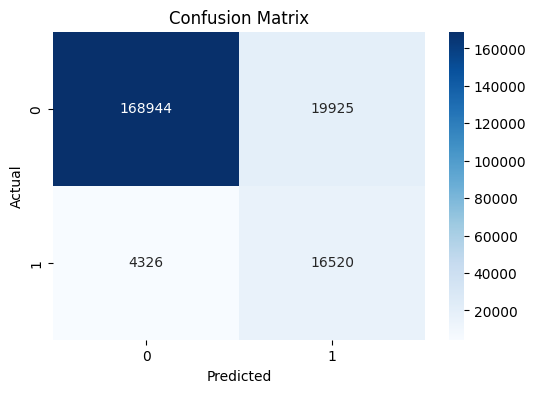

Model saved as 'random_forest_model.joblib'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_rba_dataset.csv')
X = df.drop(columns=['User ID', 'Target'])
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(" Model Evaluation Results:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
joblib.dump(model, '/content/drive/MyDrive/Colab Notebooks/random_forest_model.joblib')
print("Model saved as 'random_forest_model.joblib'")


In [ ]:
!pip install flask-ngrok



basic Flask

In [ ]:
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
app = Flask(__name__)
run_with_ngrok(app)
@app.route('/')
def index():
    return "🚀 AI Anomaly Detection Flask API is Running via Ngrok!"
@app.route('/predict', methods=['POST'])
def predict():
    return jsonify({"message": "Prediction endpoint will go here."})
app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-9:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            

In [ ]:
!pip install flask flask-ngrok


basic flask

In [ ]:
!pip install flask flask-ngrok --no-deps



In [ ]:
import os
os.kill(os.getpid(), 9)


In [ ]:
import flask
import flask_ngrok

print(" Flask version:", flask.__version__)
print("Flask-Ngrok loaded successfully")


 Flask version: 3.0.3
Flask-Ngrok loaded successfully


<ipython-input-23-61dfaf178a61>:4: DeprecationWarning:

The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.



In [ ]:
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok

app = Flask(__name__)
run_with_ngrok(app)

@app.route('/')
def index():
    return "🚀 AI Anomaly Detection Flask API is Running via Ngrok!"

@app.route('/predict', methods=['POST'])
def predict():
    return jsonify({"message": "Prediction endpoint will go here."})

app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-9:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            

In [ ]:
!pip install flask pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: blinker
    Found existing installation: blinker 1.4
error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.


In [ ]:
from flask import Flask, request, jsonify
from pyngrok import ngrok, conf
import joblib
import pandas as pd
import numpy as np
import csv


conf.get_default().auth_token = "2vsblT1BFWjH6mQexK15svyBfeS_27iLyRiSm67CLaDnPnsyZ"

app = Flask(__name__)
public_url = ngrok.connect(5000)
print("Ngrok Tunnel URL:", public_url)


model = joblib.load('/content/drive/MyDrive/Colab Notebooks/random_forest_model.joblib')
scaler = joblib.load('/content/drive/MyDrive/Colab Notebooks/encoders/minmax_scaler.joblib')

encoder_cols = ['Country', 'Region', 'City', 'ASN', 'Browser Name and Version', 'OS Name and Version', 'Device Type']
label_encoders = {}
for col in encoder_cols:
    path = f"/content/drive/MyDrive/Colab Notebooks/encoders/{col}_encoder.joblib"
    label_encoders[col] = joblib.load(path)

@app.route('/')
def index():
    return "Flask API is running with real-time anomaly detection!"

@app.route('/predict', methods=['POST'])
def predict():
    input_data = request.json
    try:
        user_id = input_data['User ID']
        input_df = pd.DataFrame([input_data])
        input_df['Login Timestamp'] = pd.to_datetime(input_df['Login Timestamp'], format='%H:%M:%S', errors='coerce')
        input_df['login_hour'] = input_df['Login Timestamp'].dt.hour.fillna(0).astype(int)
        input_df['day_of_week'] = 1
        input_df['is_weekend'] = 0
        input_df['Login Successful'] = input_df['Login Successful'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

        def safe_encode(encoder, value):
            if value in encoder.classes_:
                return encoder.transform([value])[0]
            else:
                return encoder.transform([encoder.classes_[0]])[0]

        for col in encoder_cols:
            input_df[col] = input_df[col].astype(str).apply(lambda val: safe_encode(label_encoders[col], val))

        input_df['ip_variability_score'] = 1

        scaled = scaler.transform(input_df[['login_hour', 'ASN', 'ip_variability_score']])
        input_df['login_hour_minmax'] = scaled[:, 0]
        input_df['asn_minmax'] = scaled[:, 1]
        input_df['ip_variability_minmax'] = scaled[:, 2]

        model_features = [
            'ASN', 'Device Type', 'login_hour', 'Login Successful',
            'Country', 'Region', 'City', 'Browser Name and Version',
            'OS Name and Version', 'day_of_week', 'is_weekend',
            'ip_variability_score', 'login_hour_minmax', 'asn_minmax', 'ip_variability_minmax'
        ]
        X_input = input_df[model_features]

        proba = model.predict_proba(X_input)[0][1]
        prediction = 1 if proba >= 0.2 else 0
        confidence = round(float(proba), 4)

        log_path = "/content/drive/MyDrive/Colab Notebooks/api_prediction_logs.csv"
        with open(log_path, mode="a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=["User ID", "prediction", "confidence_score"])
            if f.tell() == 0:
                writer.writeheader()
            writer.writerow({
                "User ID": user_id,
                "prediction": "anomalous" if prediction == 1 else "legitimate",
                "confidence_score": confidence
            })

        result = {
            "User ID": user_id,
            "prediction": "anomalous" if prediction == 1 else "legitimate",
            "confidence_score": confidence
        }
        return jsonify(result)

    except Exception as e:
        return jsonify({"error": str(e)})

app.run(port=5000, use_reloader=False)



ModuleNotFoundError: No module named 'flask'

🔗 Ngrok Tunnel URL: NgrokTunnel: "https://0cca-35-229-250-132.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
!pip install jupyter-dash dash pandas plotly


In [ ]:
!pip install jupyter-dash --quiet --ignore-installed




ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 6.29.5 which is incompatible.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.2.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.6.3 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.6.3 which is incompatible.


In [ ]:
from jupyter_dash import JupyterDash
print("✅ JupyterDash is ready!")


✅ JupyterDash is ready!


In [ ]:
!pip install jupyter-dash


In [ ]:
# Install required packages
!pip install dash pyngrok --quiet


In [ ]:
!pip install dash==2.14.2  # Version known to work well with Colab


In [ ]:
!pip install pyngrok


In [ ]:
import pandas as pd
from dash import Dash, dcc, html
import plotly.express as px
from pyngrok import ngrok
import threading


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/api_predictions.csv")


df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'], format="%H:%M:%S", errors='coerce')
df['Hour'] = df['Login Timestamp'].dt.hour


app = Dash(__name__)
server = app.server
app.title = "Cloud Login Anomaly Dashboard"


pie_fig = px.pie(
    df,
    names="Prediction",
    title="Anomaly vs Legitimate Logins",
    hole=0.4,
    color_discrete_sequence=px.colors.sequential.Rainbow
)
pie_fig.update_traces(textinfo='percent+label', pull=[0.05, 0], showlegend=True)


hourly_count = df.groupby(['Hour', 'Prediction']).size().reset_index(name='Count')
line_fig = px.line(
    hourly_count,
    x="Hour",
    y="Count",
    color="Prediction",
    title="Login Activity by Hour",
    line_shape="spline",
    markers=True,
    color_discrete_sequence=px.colors.sequential.Plasma
)
line_fig.update_layout(xaxis_title="Hour of Day", yaxis_title="Number of Logins")


top_asn = df['ASN'].value_counts().nlargest(10).reset_index()
top_asn.columns = ['ASN', 'Count']
asn_fig = px.bar(
    top_asn,
    x='ASN',
    y='Count',
    title='Top 10 ASN Frequencies',
    text_auto=True,
    color='Count',
    color_continuous_scale='Turbo'
)
asn_fig.update_layout(xaxis_tickangle=-45)


user_anomalies = df[df["Prediction"] == "anomalous"]['User ID'].value_counts().nlargest(10).reset_index()
user_anomalies.columns = ['User ID', 'Anomaly Count']
user_fig = px.bar(
    user_anomalies,
    x='User ID',
    y='Anomaly Count',
    title='Top 10 Users with Most Anomalies',
    text_auto=True,
    color='Anomaly Count',
    color_continuous_scale='Inferno'
)
user_fig.update_layout(xaxis_tickangle=-45)


app.layout = html.Div([
    html.H1("AI-Driven Authentication Anomaly Dashboard", style={"textAlign": "center", "marginBottom": "20px"}),
    html.Div([
        dcc.Graph(figure=pie_fig),
        dcc.Graph(figure=line_fig),
        dcc.Graph(figure=asn_fig),
        dcc.Graph(figure=user_fig)
    ], style={"display": "grid", "gridTemplateColumns": "1fr", "gap": "40px"})
], style={"width": "95%", "margin": "auto", "fontFamily": "Arial, sans-serif"})


public_url = ngrok.connect(8050)
print(" Public Dashboard Link:", public_url)

def run_dash():
    app.run(host='0.0.0.0', port=8050, debug=False, use_reloader=False)

thread = threading.Thread(target=run_dash)
thread.start()


 Public Dashboard Link: NgrokTunnel: "https://3048-34-42-37-101.ngrok-free.app" -> "http://localhost:8050"


In [ ]:

!pip install dash==2.14.2 pyngrok pandas plotly




In [ ]:



import pandas as pd
from dash import Dash, dcc, html
import plotly.express as px
from pyngrok import ngrok
import threading
ngrok.set_auth_token("2vsblT1BFWjH6mQexK15svyBfeS_27iLyRiSm67CLaDnPnsyZ")
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/api_predictions.csv")
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'], format="%H:%M:%S", errors='coerce')
df['Hour'] = df['Login Timestamp'].dt.hour
pie_fig = px.pie(df, names="Prediction", title="Anomaly vs Legitimate Logins", hole=0.4)
hourly_count = df.groupby(['Hour', 'Prediction']).size().reset_index(name='Count')
line_fig = px.line(hourly_count, x="Hour", y="Count", color="Prediction", title="Login Activity by Hour")
asn_freq = df['ASN'].value_counts().nlargest(10).reset_index()
asn_freq.columns = ['ASN', 'Count']
asn_fig = px.bar(asn_freq, x='ASN', y='Count', title='Top 10 ASN Frequencies')
user_anomalies = df[df["Prediction"] == "anomalous"]['User ID'].value_counts().reset_index()
user_anomalies.columns = ['User ID', 'Anomaly Count']
user_fig = px.bar(user_anomalies, x='User ID', y='Anomaly Count', title='Users with Most Anomalies')
app = Dash(__name__)
server = app.server
app.layout = html.Div([
    html.H1("AI-Driven Authentication Dashboard", style={"textAlign": "center"}),
    dcc.Graph(figure=pie_fig),
    dcc.Graph(figure=line_fig),
    dcc.Graph(figure=asn_fig),
    dcc.Graph(figure=user_fig)
])

public_url = ngrok.connect(8050)
print(" Public Dashboard Link:", public_url)
def run_dash():
    app.run_server(debug=False, use_reloader=False, port=8050)
thread = threading.Thread(target=run_dash)
thread.start()


🔗 Public Dashboard Link: NgrokTunnel: "https://bf2c-35-188-226-138.ngrok-free.app" -> "http://localhost:8050"


In [ ]:
from flask import Flask, request, jsonify
from pyngrok import ngrok, conf
import joblib
import pandas as pd
import numpy as np
import csv
from datetime import datetime

# 🔐 Step 0: Set ngrok authtoken
conf.get_default().auth_token = "2vsblT1BFWjH6mQexK15svyBfeS_27iLyRiSm67CLaDnPnsyZ"

# Step 1: Initialize Flask
app = Flask(__name__)
public_url = ngrok.connect(5000)
print(" Ngrok Tunnel URL:", public_url)

# Step 2: Load model and scaler
model = joblib.load('/content/drive/MyDrive/Colab Notebooks/random_forest_model.joblib')
scaler = joblib.load('/content/drive/MyDrive/Colab Notebooks/encoders/minmax_scaler.joblib')

# Step 3: Load label encoders
encoder_cols = ['Country', 'Region', 'City', 'ASN',
                'Browser Name and Version', 'OS Name and Version', 'Device Type']
label_encoders = {}
for col in encoder_cols:
    path = f"/content/drive/MyDrive/Colab Notebooks/encoders/{col}_encoder.joblib"
    label_encoders[col] = joblib.load(path)

# Step 4: Home route
@app.route('/')
def index():
    return "🚀 Flask API is running with real-time anomaly detection!"

# Step 5: Prediction route
@app.route('/predict', methods=['POST'])
def predict():
    input_data = request.json
    try:
        user_id = input_data['User ID']
        input_df = pd.DataFrame([input_data])

        # Extract login hour
        input_df['Login Timestamp'] = pd.to_datetime(input_df['Login Timestamp'], format='%H:%M:%S', errors='coerce')
        input_df['login_hour'] = input_df['Login Timestamp'].dt.hour.fillna(0).astype(int)

        # Add static values
        input_df['day_of_week'] = 1
        input_df['is_weekend'] = 0

        # Ensure boolean compatibility
        input_df['Login Successful'] = input_df['Login Successful'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

        # Safe encoding of categorical features
        def safe_encode(encoder, value):
            if value in encoder.classes_:
                return encoder.transform([value])[0]
            else:
                return encoder.transform([encoder.classes_[0]])[0]

        for col in encoder_cols:
            input_df[col] = input_df[col].astype(str).apply(lambda val: safe_encode(label_encoders[col], val))

        # Add placeholder feature
        input_df['ip_variability_score'] = 1

        # Apply scaling
        scaled = scaler.transform(input_df[['login_hour', 'ASN', 'ip_variability_score']])
        input_df['login_hour_minmax'] = scaled[:, 0]
        input_df['asn_minmax'] = scaled[:, 1]
        input_df['ip_variability_minmax'] = scaled[:, 2]

        # Features for model
        model_features = [
            'ASN', 'Device Type', 'login_hour', 'Login Successful',
            'Country', 'Region', 'City', 'Browser Name and Version',
            'OS Name and Version', 'day_of_week', 'is_weekend',
            'ip_variability_score', 'login_hour_minmax', 'asn_minmax', 'ip_variability_minmax'
        ]

        X_input = input_df[model_features]

        # Predict
        proba = model.predict_proba(X_input)[0][1]
        prediction = 1 if proba >= 0.2 else 0
        confidence = round(float(proba), 4)

        # Log all predictions
        log_path = "/content/drive/MyDrive/Colab Notebooks/api_prediction_logs.csv"
        with open(log_path, mode="a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=["User ID", "prediction", "confidence_score"])
            if f.tell() == 0:
                writer.writeheader()
            writer.writerow({
                "User ID": user_id,
                "prediction": "anomalous" if prediction == 1 else "legitimate",
                "confidence_score": confidence
            })

        # ✅ Alert logging for anomalies
        if prediction == 1:
            alert_log_path = "/content/drive/MyDrive/Colab Notebooks/alerts_log.csv"
            alert_entry = {
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "User ID": user_id,
                "Prediction": "anomalous",
                "Confidence": confidence,
                "Login Timestamp": input_data.get("Login Timestamp"),
                "ASN": input_data.get("ASN"),
                "Device Type": input_data.get("Device Type"),
                "Country": input_data.get("Country"),
                "Region": input_data.get("Region"),
                "City": input_data.get("City"),
                "Browser": input_data.get("Browser Name and Version"),
                "OS": input_data.get("OS Name and Version")
            }

            with open(alert_log_path, mode="a", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=alert_entry.keys())
                if f.tell() == 0:
                    writer.writeheader()
                writer.writerow(alert_entry)

        # Final API response
        return jsonify({
            "User ID": user_id,
            "prediction": "anomalous" if prediction == 1 else "legitimate",
            "confidence_score": confidence
        })

    except Exception as e:
        return jsonify({"error": str(e)})

# ✅ Run the app
app.run(port=5000, use_reloader=False)


 Ngrok Tunnel URL: NgrokTunnel: "https://351f-34-42-37-101.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


In [ ]:
!pip install dash==2.14.2 pyngrok plotly


In [ ]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html
from pyngrok import ngrok
import threading
alerts_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/alerts_log.csv")
alerts_df['timestamp'] = pd.to_datetime(alerts_df['timestamp'])
alerts_df['hour'] = alerts_df['timestamp'].dt.hour
color_theme = px.colors.sequential.Plasma
timeline_fig = px.histogram(
    alerts_df, x="timestamp", nbins=24, color_discrete_sequence=["#636EFA"],
    title=" Timeline of Anomaly Alerts",
    labels={"timestamp": "Alert Timestamp"},
)
timeline_fig.update_layout(title_x=0.5, plot_bgcolor="#F9F9F9", margin=dict(l=20, r=20, t=60, b=20))
user_counts = alerts_df["User ID"].value_counts().reset_index()
user_counts.columns = ["User ID", "Anomaly Count"]
user_fig = px.bar(
    user_counts, x="User ID", y="Anomaly Count",
    title=" Users with Most Alerts", color_discrete_sequence=["#00CC96"]
)
user_fig.update_layout(title_x=0.5, plot_bgcolor="#F9F9F9")
confidence_fig = px.histogram(
    alerts_df, x="Confidence", nbins=10,
    title="Anomaly Confidence Score Distribution",
    labels={"Confidence": "Prediction Confidence"},
    color_discrete_sequence=["#AB63FA"]
)
confidence_fig.update_layout(title_x=0.5, plot_bgcolor="#F9F9F9")
app = Dash(__name__)
server = app.server
app.layout = html.Div(style={"fontFamily": "Arial, sans-serif", "padding": "20px"}, children=[
    html.H1(" AI-Driven Alerting System Dashboard", style={"textAlign": "center", "color": "#333"}),
    html.H2(" Visual Analytics", style={"marginTop": "30px", "color": "#444"}),
    dcc.Graph(figure=timeline_fig),
    dcc.Graph(figure=user_fig),
    dcc.Graph(figure=confidence_fig),
    html.H2(" Recent Alerts (Last 10 Entries)", style={"marginTop": "40px", "color": "#444"}),
    html.Table([
        html.Thead(html.Tr([html.Th(col, style={"padding": "8px", "borderBottom": "1px solid #ccc"}) for col in alerts_df.columns])),
        html.Tbody([
            html.Tr([
                html.Td(alerts_df.iloc[i][col], style={"padding": "6px", "borderBottom": "1px solid #eee"}) for col in alerts_df.columns])
            for i in range(min(10, len(alerts_df)))
        ])
    ], style={
        "width": "100%", "border": "1px solid #ccc",
        "borderCollapse": "collapse", "marginTop": "10px", "fontSize": "14px" })
    ])
public_url = ngrok.connect(8050)
print("Public Dashboard URL:", public_url)
def run_dash():
    app.run_server(debug=False, use_reloader=False, port=8050)
thread = threading.Thread(target=run_dash)
thread.start()



Public Dashboard URL: NgrokTunnel: "https://2d4d-34-42-37-101.ngrok-free.app" -> "http://localhost:8050"


Exception in thread Thread-100 (run_dash):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "<ipython-input-60-f506afb5e950>", line 53, in run_dash
  File "/usr/local/lib/python3.11/dist-packages/dash/_obsolete.py", line 22, in __getattr__
    raise err.exc(err.message)
dash.exceptions.ObsoleteAttributeException: app.run_server has been replaced by app.run


In [ ]:
"/content/drive/MyDrive/Colab Notebooks/api_prediction_logs.csv"


'/content/drive/MyDrive/Colab Notebooks/api_prediction_logs.csv'

In [ ]:
!pip install dash plotly pyngrok

In [ ]:
import pandas as pd
import plotly.express as px
from dash import Dash, html, dcc
from pyngrok import ngrok, conf


# Set ngrok token (optional)
conf.get_default().auth_token = "2vsblT1BFWjH6mQexK15svyBfeS_27iLyRiSm67CLaDnPnsyZ"

# Load and prepare data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/api_prediction_logs.csv")
df['User ID'] = df['User ID'].astype(str)

# Filter anomalies
anomalies = df[df['prediction'] == 'anomalous']

# Count anomalies per user
user_anomaly_counts = (
    anomalies.groupby('User ID')
    .size()
    .reset_index(name='Anomaly Count')
    .sort_values(by='Anomaly Count', ascending=False)
    .head(10)
)

# Plot vertical bar chart with clean matching style
fig = px.bar(
    user_anomaly_counts,
    x='User ID',
    y='Anomaly Count',
    text='Anomaly Count',
    title='Users with Most Anomalies'
)

fig.update_traces(
    marker_color='rgba(99, 110, 250, 0.9)',  # same blue tone as other graphs
    textposition='outside'
)

fig.update_layout(
    xaxis_title='User ID',
    yaxis_title='Anomaly Count',
    plot_bgcolor='white',
    font=dict(size=12),
    title=dict(x=0.5, font=dict(size=20)),
    margin=dict(l=40, r=40, t=60, b=100),
    xaxis_tickangle=-45  # tilted labels to avoid overlap
)

# Build Dash app
app = Dash(__name__)
app.layout = html.Div([
    html.H2("Anomaly Detection Dashboard"),
    html.P("Figure 6.7 – Users with the Highest Number of Anomalies"),
    dcc.Graph(figure=fig)
])

# Run via ngrok
public_url = ngrok.connect(8050)
print(f"🔗 Public URL: {public_url}")
app.run_server(port=8050)


🔗 Public URL: NgrokTunnel: "https://4bda-35-194-174-238.ngrok-free.app" -> "http://localhost:8050"


ObsoleteAttributeException: app.run_server has been replaced by app.run

In [ ]:
!pip install dash dash-table jupyter-dash pyngrok --quiet --ignore-installed



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 6.29.5 which is incompatible.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.2.0 which is incompatible.
opentelemetry-api 1.32.1 requires importlib-metadata<8.7.0,>=6.0, but you have importlib-metadata 8.7.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.6.3 which is incompatible.
langchain-core 0.3.56 requires packaging<25,>=23.2, but you have packaging 25.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvid

In [ ]:
import pandas as pd
from dash import Dash, dcc, html, dash_table
import plotly.express as px
from pyngrok import ngrok
import threading
from pyngrok import conf

# === Load Alert Log ===
conf.get_default().auth_token = "2vsblT1BFWjH6mQexK15svyBfeS_27iLyRiSm67CLaDnPnsyZ"
alert_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/alerts_log.csv")

# Parse timestamp for plotting
alert_df['timestamp'] = pd.to_datetime(alert_df['timestamp'], errors='coerce')
alert_df['hour'] = alert_df['timestamp'].dt.hour

# === Initialize Dash App ===
app = Dash(__name__)
app.title = "AI-Driven Alerting System Dashboard"
server = app.server

# === Timeline of Alerts (Histogram) ===
timeline_fig = px.histogram(
    alert_df,
    x="timestamp",
    title="Timeline of Anomaly Alerts",
    color_discrete_sequence=["#636EFA"],  # vivid blue
)
timeline_fig.update_layout(xaxis_title="Alert Timestamp", yaxis_title="count")

# === Users with Most Alerts ===
user_alerts = alert_df['User ID'].value_counts().nlargest(10).reset_index()
user_alerts.columns = ['User ID', 'Anomaly Count']
user_fig = px.bar(
    user_alerts,
    x="User ID",
    y="Anomaly Count",
    title="Users with Most Alerts",
    color='Anomaly Count',
    color_continuous_scale='Viridis',  # clean vibrant gradient
    text_auto=True
)
user_fig.update_layout(xaxis_tickangle=-30)

# === Confidence Score Distribution ===
conf_fig = px.histogram(
    alert_df,
    x="Confidence",
    title="Anomaly Confidence Score Distribution",
    color_discrete_sequence=["#AB63FA"],  # vivid purple
)
conf_fig.update_layout(xaxis_title="Prediction Confidence", yaxis_title="count")

# === Recent Alerts Table ===
table_data = alert_df.sort_values("timestamp", ascending=False).head(10)

# === Layout ===
app.layout = html.Div([
    html.H1("AI-Driven Alerting System Dashboard", style={"textAlign": "center", "marginBottom": "10px"}),
    html.H3("Visual Analytics", style={"marginLeft": "20px"}),

    dcc.Graph(figure=timeline_fig),
    dcc.Graph(figure=user_fig),
    dcc.Graph(figure=conf_fig),

    html.H3("Recent Alerts (Last 10 Entries)", style={"marginTop": "40px", "marginLeft": "20px"}),
    dash_table.DataTable(
        data=table_data.to_dict('records'),
        columns=[{"name": i, "id": i} for i in table_data.columns],
        style_table={"overflowX": "auto", "margin": "0 20px"},
        style_cell={"textAlign": "left", "minWidth": "100px", "whiteSpace": "normal"},
        page_size=10
    )
], style={"width": "95%", "margin": "auto", "fontFamily": "Arial, sans-serif"})

# === Launch with ngrok ===
public_url = ngrok.connect(8050)
print(" Alerting Dashboard is live at:", public_url)

def run_dash():
    app.run(host='0.0.0.0', port=8050, debug=False, use_reloader=False)

threading.Thread(target=run_dash).start()


 Alerting Dashboard is live at: NgrokTunnel: "https://dff3-34-42-37-101.ngrok-free.app" -> "http://localhost:8050"
